<a href="https://colab.research.google.com/github/MarwaAyash/TB-project/blob/MarwaAyash/TB_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [249]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [250]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split, GroupKFold, GroupShuffleSplit
from pandas.api.types import is_numeric_dtype, is_object_dtype
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import fbeta_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
import xgboost as xgb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [251]:
data_path = "/content/drive/MyDrive/solicited_combined_database.pkl"
data = pd.read_pickle(data_path)

print("Data loaded:", data.shape)
print("\nData overview:")
display(data.head())


print(f"Total unique participants: {data['participant'].nunique()}")
print(f"Total records: {len(data)}")
print(f"Average records per participant: {len(data) / data['participant'].nunique():.2f}")

Data loaded: (9772, 29)

Data overview:


,participant,sex,age,height,weight,reported_cough_dur,tb_prior,tb_prior_Pul,tb_prior_Extrapul,tb_prior_Unknown,...,Country,Numberofcoughsoundscollected,HIVstatus,Microbiologicreferencestandard,Sputumxpertreferencestandard,Xpertcombinedsemiquant,filename,sound_prediction_score,sample_rate,audio_signal
0,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088710003-recording-1.wav,0.990254,44100,"[518, 408, 353, 359, 350, 374, 304, 336, 345, ..."
1,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088760390-recording-1.wav,0.990272,44100,"[773, 773, 794, 808, 784, 753, 740, 744, 764, ..."
2,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088760830-recording-1.wav,0.990112,44100,"[-54, -41, -20, -10, -19, -8, 8, 27, 37, 53, 3..."
3,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088710843-recording-1.wav,0.990152,44100,"[-6, -36, -63, -71, -49, -14, -10, -9, -35, -2..."
4,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088759950-recording-1.wav,0.990039,44100,"[72, 37, 22, 53, 92, 98, 61, 42, 64, 58, 40, 4..."


Total unique participants: 1082
Total records: 9772
Average records per participant: 9.03


In [252]:
# Valeurs manquantes
missing_values = data.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print("\nColonnes avec valeurs manquantes:")
print(missing_values)


Colonnes avec valeurs manquantes:
Xpertcombinedsemiquant            7110
HIVstatus                           25
height                              23
Microbiologicreferencestandard       4
dtype: int64


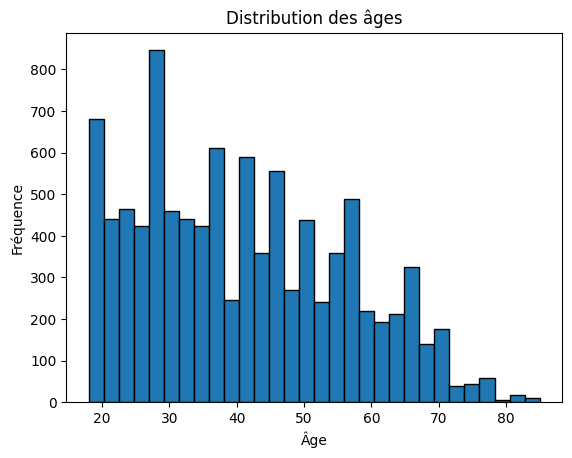

sex
Male      5023
Female    4749
Name: count, dtype: int64
Country
UG    2166
VN    1791
PH    1356
MG    1293
SA    1119
IN    1043
TZ    1004
Name: count, dtype: int64


In [253]:
import matplotlib.pyplot as plt

# Histogramme des âges
plt.hist(data['age'], bins=30, edgecolor='black')
plt.title("Distribution des âges")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

# Sexe
print(data['sex'].value_counts())

# Pays
print(data['Country'].value_counts().head(10))

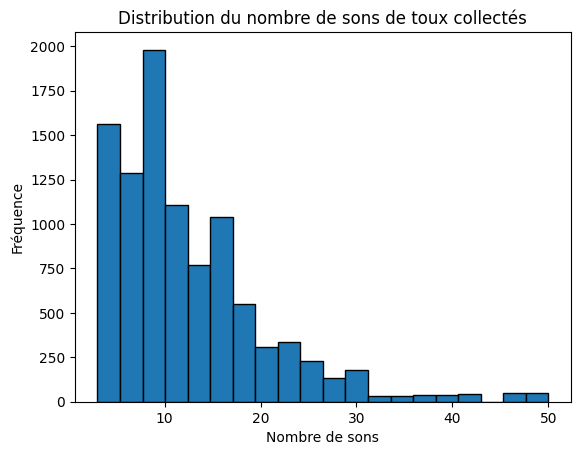

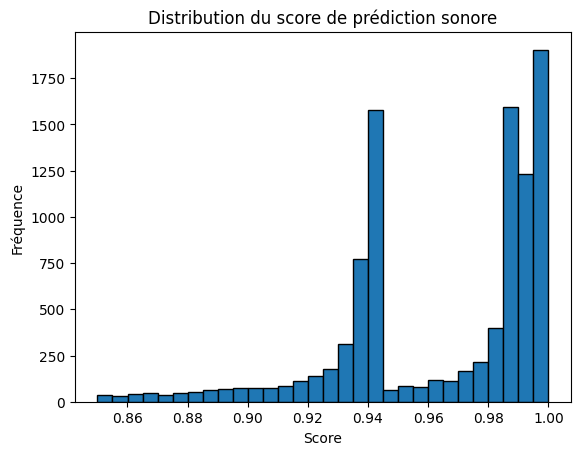

In [254]:
plt.hist(data['Numberofcoughsoundscollected'], bins=20, edgecolor='black')
plt.title("Distribution du nombre de sons de toux collectés")
plt.xlabel("Nombre de sons")
plt.ylabel("Fréquence")
plt.show()

plt.hist(data['sound_prediction_score'], bins=30, edgecolor='black')
plt.title("Distribution du score de prédiction sonore")
plt.xlabel("Score")
plt.ylabel("Fréquence")
plt.show()

In [255]:
# Features cliniques
CLINICAL_FEATURES = [
    "age", "height", "weight", "BMI", "reported_cough_dur",
    "heart_rate", "temperature", "weight_loss", "smoke_lweek",
    "fever", "night_sweats",
]

# Cible
target_col = "tb_status"

#  Colonnes à supprimer pour éviter les fuites
cols_to_drop = [
    "Microbiologicreferencestandard", "Sputumxpertreferencestandard",
    "sound_prediction_score", "Xpertcombinedsemiquant", "HIVstatus",
    "tb_prior", "tb_prior_Pul", "tb_prior_Extrapul", "tb_prior_Unknown",
    "filename", "type", "Country", "Numberofcoughsoundscollected"
]

data = data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors="ignore")
# Supprimer les lignes sans target
data = data.dropna(subset=[target_col])
# Supprimer les doublons par participant
data = data.drop_duplicates(subset=["participant"])

print(f"Shape après nettoyage: {data.shape}")


Shape après nettoyage: (1082, 16)


In [256]:
def extract_simple_audio_features(audio_signal, sample_rate, n_mfcc=13):
    try:
        y = np.asarray(audio_signal, dtype=np.float32)
        # Normalisation
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))

        # # Extraction des features
        mfccs = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=n_mfcc)

        # Features spectrales simples
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sample_rate)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sample_rate)

        # Extraire les statistiques de base
        features = []
        # MFCC
        for i in range(mfccs.shape[0]):
          coeff = mfccs[i, :]
          features.extend([
          np.mean(coeff),
          np.std(coeff),
          np.min(coeff),
          np.max(coeff)
        ])
        # Centroid + Rolloff
        for feature_matrix in [spectral_centroid, spectral_rolloff]:
          features.extend([
              np.mean(feature_matrix),
              np.std(feature_matrix),
              np.min(feature_matrix),
              np.max(feature_matrix)
          ])

        return np.array(features)



    except Exception as e:
        return np.zeros(13 * 4 + 1 * 4 + 1 * 4)

# Extraction des features audio
audio_features = []
for i, row in data.iterrows():
    if "audio_signal" in row and "sample_rate" in row:
        audio_features.append(extract_simple_audio_features(row["audio_signal"], row["sample_rate"]))
    else:
        audio_features.append(np.zeros(13 * 4 + 1 * 4 + 1 * 4))

# Créer les noms de colonnes
columns = []

for prefix, n_feat in [('mfcc', 13), ('centroid', 1), ('rolloff', 1)]:
    for i in range(n_feat):
        for stat in ["mean", "std", "min", "max"]:
            if n_feat > 1:  # pour les MFCC
                columns.append(f"{prefix}_{i+1}_{stat}")
            else:            # pour centroid et rolloff
                columns.append(f"{prefix}_{stat}")

audio_df = pd.DataFrame(audio_features, columns=columns)
# Concaténation des MFCC avec le dataset principal
data = pd.concat([data.reset_index(drop=True), audio_df], axis=1)
# Supprimer les colonnes audio brutes
data = data.drop(columns=["audio_signal", "sample_rate"], errors="ignore")

print(f"{len(columns)} audio features extracted")

60 audio features extracted


In [257]:
# Aggregate multiple recordings per participant
aggregated = []
for pid, group in data.groupby("participant"):
    row = {"participant": pid}
    # Pour chaque participant, la valeur de tb_status est celle du premier enregistrement
    row[target_col] = group[target_col].iloc[0]
    for col in group.columns:
        if col not in ["participant", target_col]:
          try:
            col_data = group[col]
            # Si la colonne est une série
            if hasattr(col_data, 'dtype'):
              if col_data.dtype == 'object':
                # Pour les colonnes catégorielles, on prend la valeur la plus fréquente
                row[col] = col_data.mode().iloc[0] if not col_data.mode().empty else col_data.iloc[0]
              else:
                # Pour les colonnes numériques, on prend la moyenne
                row[col] = col_data.mean()
            else:
              # si c'est un dataframe, on prend la moyenne de la première colonne
              row[col] = col_data.iloc[:, 0].mean()
          except:
            # En cas d'erreur
            # on prend la première valeur disponible
            row[col] = group[col].iloc[0]

    aggregated.append(row)
# Création d'un nouveau DataFrame avec un enregistrement par participant
data_aggregated = pd.DataFrame(aggregated)
print(f"Dataset final après agrégation: {data_aggregated.shape}")

Dataset final après agrégation: (1082, 74)


In [258]:
# Préparer les features
clinical_features = [c for c in CLINICAL_FEATURES if c in data_aggregated.columns]
audio_features = [col for col in data_aggregated.columns if any(x in col for x in ['mfcc', 'centroid', 'rolloff'])]
SELECTED_FEATURES = clinical_features + audio_features

print(f"Nombre total de features: {len(SELECTED_FEATURES)}")
print(f"Features cliniques: {len(clinical_features)}")
print(f"Features audio: {len(audio_features)}")

X = data_aggregated[SELECTED_FEATURES].copy()
y = data_aggregated[target_col]

# Split avec GroupShuffleSplit pour éviter les fuites
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=data_aggregated["participant"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
participants_train = data_aggregated["participant"].iloc[train_idx]
participants_test = data_aggregated["participant"].iloc[test_idx]

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print("Train distribution:", y_train.value_counts(normalize=True))
print("Test distribution:", y_test.value_counts(normalize=True))

Nombre total de features: 70
Features cliniques: 10
Features audio: 60

Train: (865, 70), Test: (217, 70)
Train distribution: tb_status
0    0.739884
1    0.260116
Name: proportion, dtype: float64
Test distribution: tb_status
0    0.695853
1    0.304147
Name: proportion, dtype: float64


In [259]:
# Vérification des fuites
train_participants = set(participants_train)
test_participants = set(participants_test)
print(f"\nParticipant overlap check: {len(train_participants.intersection(test_participants))}")


Participant overlap check: 0


In [260]:
def simple_preprocessing(X_tr, X_val=None):
    # Prétraitement conservateur pour éviter l'overfitting

    X_tr_processed = X_tr.copy()

    if X_val is not None:
        X_val_processed = X_val.copy()

    # Séparer les colonnes numériques et catégorielles
    num_cols = X_tr_processed.select_dtypes(include=np.number).columns
    cat_cols = X_tr_processed.select_dtypes(include="object").columns

    # Imputation numérique robuste
    if len(num_cols) > 0:
        imputer = SimpleImputer(strategy="median")
        X_tr_processed[num_cols] = imputer.fit_transform(X_tr_processed[num_cols])
        if X_val is not None:
            X_val_processed[num_cols] = imputer.transform(X_val_processed[num_cols])

    # Encodage catégoriel simple

    for col in cat_cols:
        le = LabelEncoder()
        X_tr_processed[col] = le.fit_transform(X_tr_processed[col].astype(str))
        if X_val is not None:
            X_val_processed[col] = le.transform(X_val_processed[col].astype(str))

    # Normalisation robuste
    scaler = StandardScaler()
    if len(num_cols) > 0:
        X_tr_processed[num_cols] = scaler.fit_transform(X_tr_processed[num_cols])
        if X_val is not None:
            X_val_processed[num_cols] = scaler.transform(X_val_processed[num_cols])

    if X_val is not None:
        return X_tr_processed, X_val_processed
    else:
        return X_tr_processed



In [261]:
def calculate_all_metrics(y_true, y_pred, y_proba=None):
    # Calculer toutes les métriques
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred)
    f15 = fbeta_score(y_true, y_pred, beta=1.5)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else 0

    return {
        'auc': auc,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f15': f15,
        'confusion_matrix': cm
    }

In [262]:
def optimize_threshold(y_true, y_proba, beta=1.5):
    """
    Fonction originale qui optimise pour F-beta score
    """
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh, best_fbeta = 0.5, 0
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        fbeta = fbeta_score(y_true, y_pred, beta=beta)
        if fbeta > best_fbeta:
            best_fbeta = fbeta
            best_thresh = t
    return best_thresh, best_fbeta

Dataset characteristics:
 Samples: 865
 Total features: 70
 Feature/Sample ratio: 0.081

 Base k (n_samples/12): 72
 Low feature ratio (<0.1) - applying bonus: 1.2
   Adjusted k: 86

 Statistical bounds:
   Sqrt bound: 29
   30% of features: 21
   35% of features: 24
   40% of features: 28
  Selected upper bound: 24
  Candidate k: 24

 Final k calculation:
   Minimum k: 10
   Final k: 24 (34.3% of total features)

 Feature quality metrics:
 Mean score: 0.0299
 Min score: 0.0120
 Max score: 0.0566
 Std score: 0.0139

 Selected 24 features dynamically

 Feature composition:
 Clinical: 9/10 (90%)
 Audio: 15/60 (25%)

 Clinical features: ['age', 'height', 'weight', 'reported_cough_dur', 'heart_rate', 'temperature', 'weight_loss', 'fever', 'night_sweats']

 Top 10 audio features: ['mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_min', 'mfcc_5_std', 'mfcc_6_max', 'mfcc_7_max', 'mfcc_8_max', 'mfcc_9_std', 'mfcc_10_min', 'mfcc_12_max']

 Dataset shapes after selection:
 Train: (865, 24)
 Test: (217, 24)
 

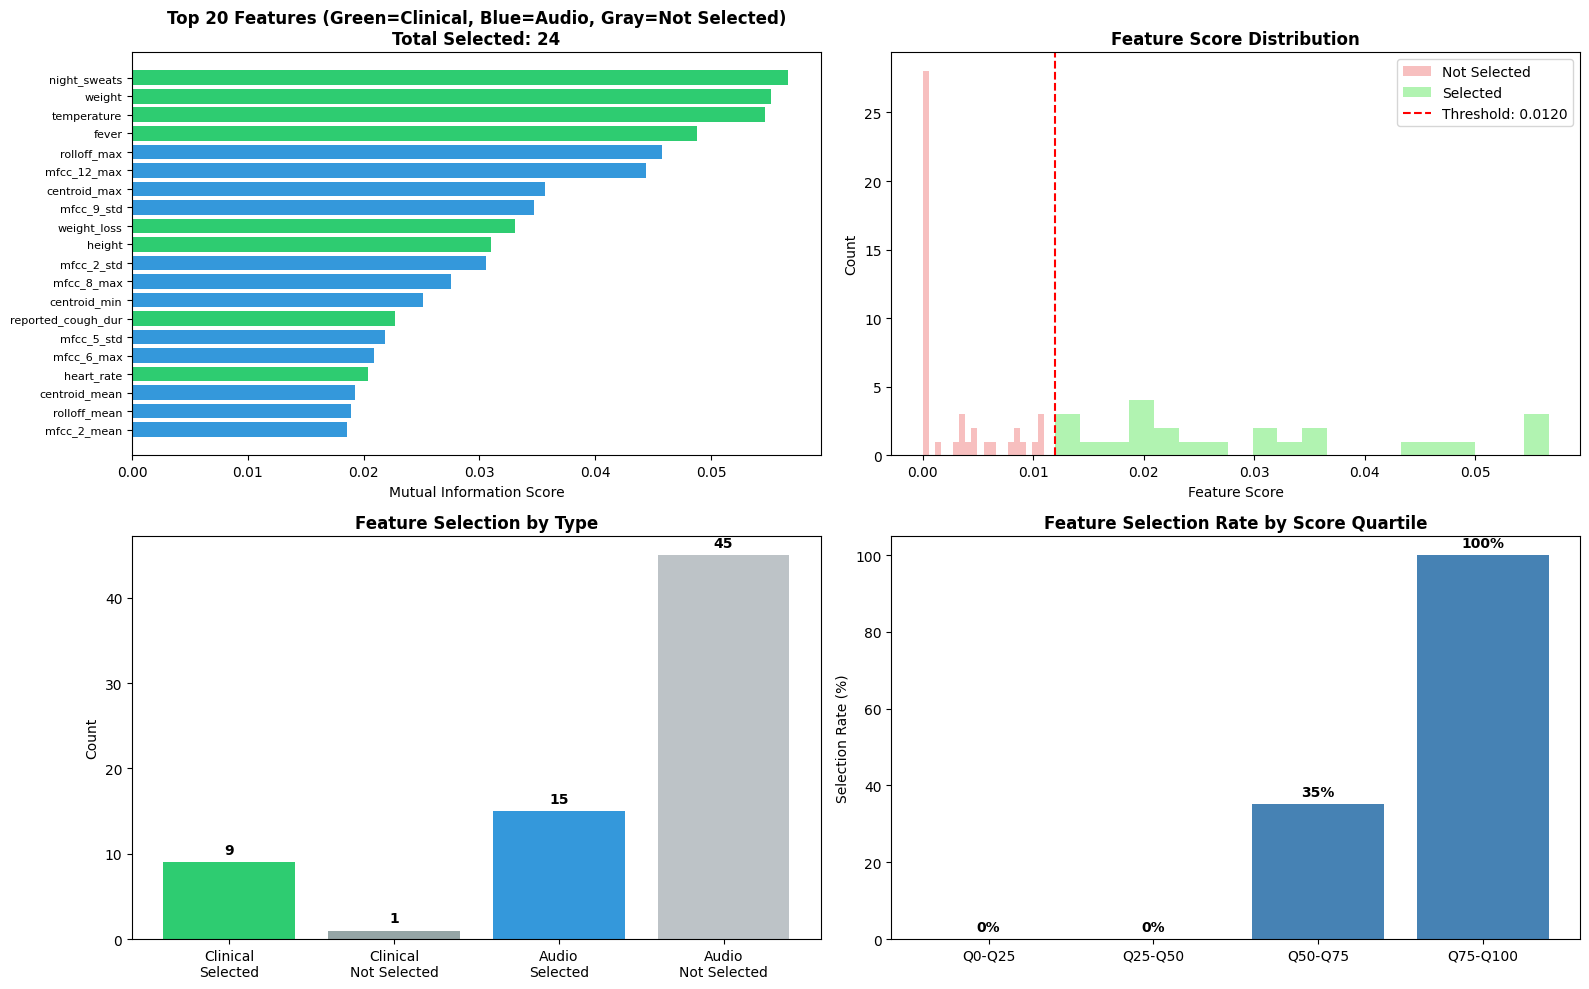

In [263]:
def dynamic_feature_selection(X, y):

    X_processed = simple_preprocessing(X)

    n_samples, n_features = X.shape
    feature_ratio = n_features / n_samples


    print(f"Dataset characteristics:")
    print(f" Samples: {n_samples}")
    print(f" Total features: {n_features}")
    print(f" Feature/Sample ratio: {feature_ratio:.3f}")

    # Calculate base k using conservative percentage
    samples_per_feature_target = 12  # Conservative target: 1 feature per 12 samples
    k_base = int(n_samples / samples_per_feature_target)
    print(f"\n Base k (n_samples/{samples_per_feature_target}): {k_base}")

    # Apply adjustment based on feature ratio
    if feature_ratio > 0.5:
        # Too many features relative to samples
        penalty_factor = 0.5
        print(f" High feature ratio (>{0.5:.1f}) - applying penalty: {penalty_factor}")
    elif feature_ratio > 0.3:
        # Moderate feature ratio - some penalty
        penalty_factor = 0.7
        print(f" Moderate feature ratio (>{0.3:.1f}) - applying penalty: {penalty_factor}")
    elif feature_ratio < 0.1:
        # Low feature ratio - can afford slightly more features
        penalty_factor = 1.2
        print(f" Low feature ratio (<{0.1:.1f}) - applying bonus: {penalty_factor}")
    else:
        # Balanced ratio - no adjustment
        penalty_factor = 1.0
        print(f" Balanced feature ratio - no adjustment")

    k_adjusted = int(k_base * penalty_factor)
    print(f"   Adjusted k: {k_adjusted}")

    # Apply statistical upper bound (sqrt rule)
    k_sqrt_bound = int(np.sqrt(n_samples))
    print(f"\n Statistical bounds:")
    print(f"   Sqrt bound: {k_sqrt_bound}")
    print(f"   30% of features: {int(n_features * 0.3)}")
    print(f"   35% of features: {int(n_features * 0.35)}")
    print(f"   40% of features: {int(n_features * 0.4)}")

    # Apply conservative upper bound (35% of features)
    k_max = min(k_sqrt_bound, int(n_features * 0.35))
    k_candidate = min(k_adjusted, k_max)
    print(f"  Selected upper bound: {k_max}")
    print(f"  Candidate k: {k_candidate}")

    # Apply minimum bound (at least 10 features or 10% of total)
    k_min = max(10, int(n_features * 0.1))
    k_final = max(k_min, min(k_candidate, n_features))

    print(f"\n Final k calculation:")
    print(f"   Minimum k: {k_min}")
    print(f"   Final k: {k_final} ({k_final/n_features:.1%} of total features)")

    # Select features using mutual information
    selector = SelectKBest(mutual_info_classif, k=k_final)
    selector.fit(X_processed, y)

    # Check feature quality
    selected_scores = selector.scores_[selector.get_support()]
    print(f"\n Feature quality metrics:")
    print(f" Mean score: {np.mean(selected_scores):.4f}")
    print(f" Min score: {np.min(selected_scores):.4f}")
    print(f" Max score: {np.max(selected_scores):.4f}")
    print(f" Std score: {np.std(selected_scores):.4f}")

    # Filter out very weak features if score threshold is too low
    score_threshold = np.percentile(selector.scores_, 60)  # Keep top 40%
    if np.min(selected_scores) < score_threshold * 0.1:
        print(f"  Warning: Some selected features have very low scores")
        print(f"  Score threshold (60th percentile): {score_threshold:.4f}")

    selected_features = X.columns[selector.get_support()].tolist()

    # Get all feature scores for visualization
    feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_,
    'Selected': selector.get_support(),
    'Type': ['Clinical' if f in CLINICAL_FEATURES else 'Audio' for f in X.columns]}).sort_values('Score', ascending=False)

    print(f"\n Selected {len(selected_features)} features dynamically")

    return selected_features, feature_scores, k_final

# APPLY DYNAMIC FEATURE SELECTION
best_features, feature_scores, k_selected = dynamic_feature_selection(
    X_train, y_train)

# Analyze composition
clinical_selected = [f for f in best_features if f in clinical_features]
audio_selected = [f for f in best_features if f not in clinical_features]

print(f"\n Feature composition:")
print(f" Clinical: {len(clinical_selected)}/{len(clinical_features)} ({len(clinical_selected)/len(clinical_features):.0%})")
print(f" Audio: {len(audio_selected)}/{len(audio_features)} ({len(audio_selected)/len(audio_features):.0%})")
print(f"\n Clinical features: {clinical_selected}")
print(f"\n Top 10 audio features: {audio_selected[:10]}")

# Create selected datasets
X_train_selected = X_train[best_features].copy()
X_test_selected = X_test[best_features].copy()

print(f"\n Dataset shapes after selection:")
print(f" Train: {X_train_selected.shape}")
print(f" Test: {X_test_selected.shape}")
print(f" Features per sample: {X_train_selected.shape[1]/X_train_selected.shape[0]:.3f}")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top 20 features by score
ax1 = axes[0, 0]
top_20 = feature_scores.head(20)
colors = []
for _, row in top_20.iterrows():
    if row['Selected']:
        colors.append('#2ecc71' if row['Type'] == 'Clinical' else '#3498db')
    else:
        colors.append('lightgray')

ax1.barh(range(len(top_20)), top_20['Score'], color=colors)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['Feature'], fontsize=8)
ax1.set_xlabel('Mutual Information Score')
ax1.set_title(f'Top 20 Features (Green=Clinical, Blue=Audio, Gray=Not Selected)\nTotal Selected: {k_selected}', fontweight='bold')
ax1.invert_yaxis()

# Score distribution
ax2 = axes[0, 1]
selected_scores = feature_scores[feature_scores['Selected']]['Score']
non_selected_scores = feature_scores[~feature_scores['Selected']]['Score']
ax2.hist(non_selected_scores, bins=20, alpha=0.5, label='Not Selected', color='lightcoral')
ax2.hist(selected_scores, bins=20, alpha=0.7, label='Selected', color='lightgreen')
if len(selected_scores) > 0:
    ax2.axvline(np.min(selected_scores), color='red', linestyle='--',
                label=f'Threshold: {np.min(selected_scores):.4f}')
ax2.set_xlabel('Feature Score')
ax2.set_ylabel('Count')
ax2.set_title('Feature Score Distribution', fontweight='bold')
ax2.legend()

# Feature type breakdown
ax3 = axes[1, 0]
type_counts = {
    'Clinical\nSelected': len(clinical_selected),
    'Clinical\nNot Selected': len(clinical_features) - len(clinical_selected),
    'Audio\nSelected': len(audio_selected),
    'Audio\nNot Selected': len(audio_features) - len(audio_selected)
}
colors_bar = ['#2ecc71', '#95a5a6', '#3498db', '#bdc3c7']
bars = ax3.bar(range(len(type_counts)), type_counts.values(), color=colors_bar)
ax3.set_xticks(range(len(type_counts)))
ax3.set_xticklabels(type_counts.keys())
ax3.set_ylabel('Count')
ax3.set_title('Feature Selection by Type', fontweight='bold')
for i, (k, v) in enumerate(type_counts.items()):
    ax3.text(i, v + 1, str(v), ha='center', fontweight='bold')

# Selection rate by score quartile
ax4 = axes[1, 1]
quantiles = [0, 25, 50, 75, 100]
quantile_vals = np.percentile(feature_scores['Score'], quantiles)
selection_rates = []
labels = []
for i in range(len(quantiles)-1):
    mask = (feature_scores['Score'] >= quantile_vals[i]) & (feature_scores['Score'] < quantile_vals[i+1])
    if i == len(quantiles)-2:
        mask = feature_scores['Score'] >= quantile_vals[i]
    rate = feature_scores[mask]['Selected'].mean() * 100 if mask.sum() > 0 else 0
    selection_rates.append(rate)
    labels.append(f'Q{quantiles[i]}-Q{quantiles[i+1]}')

ax4.bar(range(len(selection_rates)), selection_rates, color='steelblue')
ax4.set_xticks(range(len(selection_rates)))
ax4.set_xticklabels(labels)
ax4.set_ylabel('Selection Rate (%)')
ax4.set_title('Feature Selection Rate by Score Quartile', fontweight='bold')
ax4.set_ylim([0, 105])
for i, rate in enumerate(selection_rates):
    ax4.text(i, rate + 2, f'{rate:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [264]:
from sklearn.utils.class_weight import compute_class_weight
X_train_selected = X_train[best_features].copy()
X_test_selected = X_test[best_features].copy()

print(f"Final datasets after feature selection:")
print(f"Train: {X_train_selected.shape}")
print(f"Test: {X_test_selected.shape}")

# Calculate optimal class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Optimal class weights: {class_weight_dict}")

Final datasets after feature selection:
Train: (865, 24)
Test: (217, 24)
Optimal class weights: {0: np.float64(0.67578125), 1: np.float64(1.9222222222222223)}


In [265]:
# Calcul du facteur de régularisation basé sur k
reg_factor = min(1.0, k_selected / 30)
print(f"FACTEUR DE RÉGULARISATION: {reg_factor:.2f}")

FACTEUR DE RÉGULARISATION: 0.80


In [266]:
# Calcul automatique du poids positif pour XGBoost
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f" POIDS POSITIF XGBOOST: {pos_weight:.2f}")

models = {
    "LogReg_Equilibre": LogisticRegression(
        class_weight=class_weight_dict,
        C=0.5,
        max_iter=3000,
        solver='lbfgs',
        random_state=42
    ),
    "RandomForest_Optimise": RandomForestClassifier(
        n_estimators=150,
        class_weight=class_weight_dict,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    ),
    "XGBoost_Equilibre": xgb.XGBClassifier(
        scale_pos_weight=pos_weight,
        max_depth=4,
        learning_rate=0.1,
        n_estimators=100,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        eval_metric='logloss'
    ),
    "SVM_Linear": SVC(
        probability=True,
        class_weight=class_weight_dict,
        C=0.5,
        kernel='linear',  # Plus interpretable
        random_state=42
    )
}

 POIDS POSITIF XGBOOST: 2.84


In [267]:
# Validation croisée 5-fold
group_kfold = GroupKFold(n_splits=5)
cv_results = {}
groups = data_aggregated.loc[X_train_selected.index, "participant"]
for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X_train_selected, y_train, groups=groups), 1):

    print(f"FOLD {fold}")

    X_tr, X_val = X_train_selected.iloc[train_idx].copy(), X_train_selected.iloc[val_idx].copy()
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]


    print(f"Train: {X_tr.shape}, Validation: {X_val.shape}")

    # Prétraitement conservateur
    X_tr_processed, X_val_processed = simple_preprocessing(X_tr, X_val)

    # Appliquer SMOTE avec prudence
    n_minority = sum(y_tr == 1)
    k_neighbors = min(5, n_minority - 1) if n_minority > 1 else 1
    sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr_processed, y_tr)

    # Entraîner et évaluer chaque modèle
    for model_name, model in models.items():
        print(f"\nTraining {model_name} ")

        # Feature extraction & selection pour ce fold

        try:
            # Entraînement
            model.fit(X_tr_res, y_tr_res)

            # PRÉDICTIONS SUR TRAIN
            if hasattr(model, "predict_proba"):
                y_tr_proba = model.predict_proba(X_tr_res)[:, 1]
                y_tr_pred = (y_tr_proba >= 0.5).astype(int)
            else:
                y_tr_pred = model.predict(X_tr_res)
                y_tr_proba = None

            train_metrics = calculate_all_metrics(y_tr_res, y_tr_pred, y_tr_proba)

            # PRÉDICTIONS SUR VALIDATION
            if hasattr(model, "predict_proba"):
                y_val_proba = model.predict_proba(X_val_processed)[:, 1]
                threshold, _ = optimize_threshold(y_val, y_val_proba)
                y_val_pred = (y_val_proba >= threshold).astype(int)
            else:
                y_val_pred = model.predict(X_val_processed)
                y_val_proba = None
                threshold = 0.5

            val_metrics = calculate_all_metrics(y_val, y_val_pred, y_val_proba)


            # Stocker les résultats
            if fold not in cv_results:
                cv_results[fold] = {}
            cv_results[fold][model_name] = {
                'train_metrics': train_metrics,
                'val_metrics': val_metrics,
                'threshold': threshold
            }

            # Afficher les métriques
            print(f" {model_name} - Fold {fold}")
            print(f"   TRAIN:     AUC={train_metrics['auc']:.3f}, ACC={train_metrics['accuracy']:.3f}")
            print(f"   VALIDATION: AUC={val_metrics['auc']:.3f}, ACC={val_metrics['accuracy']:.3f}")

        except Exception as e:
            print(f" Error in {model_name}: {e}")

FOLD 1
Train: (692, 24), Validation: (173, 24)

Training LogReg_Equilibre 
 LogReg_Equilibre - Fold 1
   TRAIN:     AUC=0.830, ACC=0.705
   VALIDATION: AUC=0.803, ACC=0.711

Training RandomForest_Optimise 
 RandomForest_Optimise - Fold 1
   TRAIN:     AUC=0.984, ACC=0.868
   VALIDATION: AUC=0.781, ACC=0.757

Training XGBoost_Equilibre 
 XGBoost_Equilibre - Fold 1
   TRAIN:     AUC=0.998, ACC=0.957
   VALIDATION: AUC=0.795, ACC=0.711

Training SVM_Linear 
 SVM_Linear - Fold 1
   TRAIN:     AUC=0.825, ACC=0.755
   VALIDATION: AUC=0.798, ACC=0.740
FOLD 2
Train: (692, 24), Validation: (173, 24)

Training LogReg_Equilibre 
 LogReg_Equilibre - Fold 2
   TRAIN:     AUC=0.837, ACC=0.708
   VALIDATION: AUC=0.767, ACC=0.699

Training RandomForest_Optimise 
 RandomForest_Optimise - Fold 2
   TRAIN:     AUC=0.983, ACC=0.887
   VALIDATION: AUC=0.736, ACC=0.486

Training XGBoost_Equilibre 
 XGBoost_Equilibre - Fold 2
   TRAIN:     AUC=0.999, ACC=0.961
   VALIDATION: AUC=0.742, ACC=0.601

Training SV

In [268]:
aggregated_metrics = {}

for model_name in models.keys():
    train_metrics_list = []
    val_metrics_list = []

    for fold in range(1, 6):
        if fold in cv_results and model_name in cv_results[fold]:
            train_metrics_list.append(cv_results[fold][model_name]['train_metrics'])
            val_metrics_list.append(cv_results[fold][model_name]['val_metrics'])

    if train_metrics_list:
        # Calculer mean ± std pour toutes les métriques train
        train_mean = {}
        train_std = {}
        for key in train_metrics_list[0].keys():
            values = [m[key] for m in train_metrics_list]
            train_mean[key] = np.mean(values)
            train_std[key] = np.std(values)

        # Calculer mean ± std pour toutes les métriques validation
        val_mean = {}
        val_std = {}
        for key in val_metrics_list[0].keys():
            values = [m[key] for m in val_metrics_list]
            val_mean[key] = np.mean(values)
            val_std[key] = np.std(values)

        aggregated_metrics[model_name] = {
            'train_mean': train_mean,
            'train_std': train_std,
            'val_mean': val_mean,
            'val_std': val_std
        }

# Afficher les résultats agrégés
for model_name in models.keys():
    if model_name in aggregated_metrics:
        print(f"\n {model_name}:")
        print("TRAIN (mean ± std):")
        train_mean = aggregated_metrics[model_name]['train_mean']
        train_std = aggregated_metrics[model_name]['train_std']
        print(f"  AUC: {train_mean['auc']:.3f} ± {train_std['auc']:.3f}")
        print(f"  ACC: {train_mean['accuracy']:.3f} ± {train_std['accuracy']:.3f}")
        print(f"  Sensitivity: {train_mean['sensitivity']:.3f} ± {train_std['sensitivity']:.3f}")
        print(f"  Specificity: {train_mean['specificity']:.3f} ± {train_std['specificity']:.3f}")
        print(f"  F1-score: {train_mean['f15']:.3f} ± {train_std['f15']:.3f}")

        print("VALIDATION (mean ± std):")
        val_mean = aggregated_metrics[model_name]['val_mean']
        val_std = aggregated_metrics[model_name]['val_std']
        print(f"  AUC: {val_mean['auc']:.3f} ± {val_std['auc']:.3f}")
        print(f"  ACC: {val_mean['accuracy']:.3f} ± {val_std['accuracy']:.3f}")
        print(f"  Sensitivity: {val_mean['sensitivity']:.3f} ± {val_std['sensitivity']:.3f}")
        print(f"  Specificity: {val_mean['specificity']:.3f} ± {val_std['specificity']:.3f}")
        print(f"  F1-score: {val_mean['f15']:.3f} ± {val_std['f15']:.3f}")


 LogReg_Equilibre:
TRAIN (mean ± std):
  AUC: 0.837 ± 0.010
  ACC: 0.711 ± 0.013
  Sensitivity: 0.947 ± 0.003
  Specificity: 0.475 ± 0.029
  F1-score: 0.827 ± 0.004
VALIDATION (mean ± std):
  AUC: 0.785 ± 0.017
  ACC: 0.661 ± 0.051
  Sensitivity: 0.867 ± 0.052
  Specificity: 0.585 ± 0.096
  F1-score: 0.657 ± 0.023

 RandomForest_Optimise:
TRAIN (mean ± std):
  AUC: 0.987 ± 0.003
  ACC: 0.881 ± 0.009
  Sensitivity: 0.996 ± 0.001
  Specificity: 0.766 ± 0.019
  F1-score: 0.930 ± 0.005
VALIDATION (mean ± std):
  AUC: 0.769 ± 0.026
  ACC: 0.637 ± 0.115
  Sensitivity: 0.855 ± 0.084
  Specificity: 0.556 ± 0.187
  F1-score: 0.641 ± 0.037

 XGBoost_Equilibre:
TRAIN (mean ± std):
  AUC: 0.999 ± 0.001
  ACC: 0.960 ± 0.003
  Sensitivity: 1.000 ± 0.001
  Specificity: 0.919 ± 0.006
  F1-score: 0.976 ± 0.002
VALIDATION (mean ± std):
  AUC: 0.781 ± 0.020
  ACC: 0.634 ± 0.051
  Sensitivity: 0.883 ± 0.066
  Specificity: 0.545 ± 0.087
  F1-score: 0.646 ± 0.043

 SVM_Linear:
TRAIN (mean ± std):
  AUC: 0.

In [269]:
print("FINAL MODEL TRAINING ON FULL TRAINING SET")
# Préparer les données finales avec les meilleures features
X_train_final = X_train[best_features].copy()
X_test_final = X_test[best_features].copy()

# Prétraitement
X_train_processed = simple_preprocessing(X_train_final)
X_test_processed = simple_preprocessing(X_test_final)

# Appliquer SMOTE
n_minority = sum(y_train == 1)
k_neighbors = min(5, n_minority - 1) if n_minority > 1 else 1
sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = sm.fit_resample(X_train_processed, y_train)

print(f"Final training set after SMOTE: {X_train_res.shape}")

# Entraîner les modèles finaux
final_models = {}
for name, model in models.items():
    print(f"Training final {name} ")
    # Créer une nouvelle instance du modèle pour éviter toute contamination
    if name == "Model_1_LogReg":
        final_model = LogisticRegression(class_weight="balanced", C=0.01, max_iter=2000, random_state=42)
    elif name == "Model_2_SVM":
        final_model = SVC(probability=True, class_weight="balanced", C=0.01, random_state=42)
    elif name == "Model_3_RF_Reg":
        final_model = RandomForestClassifier(n_estimators=50, class_weight="balanced", max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42)
    elif name == "Model_4_XGB_Reg":
        final_model = xgb.XGBClassifier(eval_metric="logloss", max_depth=3, learning_rate=0.1, n_estimators=50, random_state=42)
    elif name == "Model_5_RF_Reg2":
        final_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", max_depth=6, min_samples_split=30, min_samples_leaf=15, random_state=42)
    else:
        final_model = model

    final_model.fit(X_train_res, y_train_res)
    final_models[name] = final_model

FINAL MODEL TRAINING ON FULL TRAINING SET
Final training set after SMOTE: (1280, 24)
Training final LogReg_Equilibre 
Training final RandomForest_Optimise 
Training final XGBoost_Equilibre 
Training final SVM_Linear 


In [270]:
final_test_results = {}
targets_achieved_count = 0

for name, model in final_models.items():

    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_processed)[:, 1]
            threshold, achieved_sensitivity = optimize_threshold(y_test, y_proba)
            y_pred = (y_proba >= threshold).astype(int)
        else:
            y_pred = model.predict(X_test_processed)
            y_proba = None
            threshold = 0.5

        test_metrics = calculate_all_metrics(y_test, y_pred, y_proba)
        final_test_results[name] = {
            'metrics': test_metrics,
            'threshold': threshold
        }

    except Exception as e:
        print(f" Error evaluating {name}: {e}")

In [271]:
# Créer le tableau de comparaison final
comparison_data = []
for model_name in final_models.keys():
    if model_name in final_test_results:
        test_metrics = final_test_results[model_name]['metrics']
        comparison_data.append({
            'Model': model_name,
            'Test_AUC': test_metrics['auc'],
            'Test_Accuracy': test_metrics['accuracy'],
            'Test_Sensitivity': test_metrics['sensitivity'],
            'Test_Specificity': test_metrics['specificity'],
            'Test_F1': test_metrics['f15'],
            'Threshold': final_test_results[model_name]['threshold']
        })

final_comparison = pd.DataFrame(comparison_data)
print(final_comparison.round(3))

# Identifier le meilleur modèle
if len(final_comparison) > 0:
    best_model_idx = final_comparison['Test_F1'].idxmax()
    best_model_row = final_comparison.loc[best_model_idx]

    print(f"\n BEST MODEL: {best_model_row['Model']}")
    print(f"   Test F1-score: {best_model_row['Test_F1']:.3f}")
    print(f"   Test AUC: {best_model_row['Test_AUC']:.3f}")
    print(f"   Sensitivity: {best_model_row['Test_Sensitivity']:.3f}")
    print(f"   Specificity: {best_model_row['Test_Specificity']:.3f}")

                   Model  Test_AUC  Test_Accuracy  Test_Sensitivity  \
0       LogReg_Equilibre     0.795          0.691             0.848   
1  RandomForest_Optimise     0.745          0.677             0.803   
2      XGBoost_Equilibre     0.780          0.650             0.833   
3             SVM_Linear     0.780          0.673             0.894   

   Test_Specificity  Test_F1  Threshold  
0             0.623    0.696       0.59  
1             0.623    0.666       0.52  
2             0.570    0.666       0.40  
3             0.576    0.706       0.33  

 BEST MODEL: SVM_Linear
   Test F1-score: 0.706
   Test AUC: 0.780
   Sensitivity: 0.894
   Specificity: 0.576


In [272]:
!pip install shap lime


Analyzing model: SVM_Linear
Using KernelExplainer


  0%|          | 0/217 [00:00<?, ?it/s]

SHAP values shape: (217, 24)


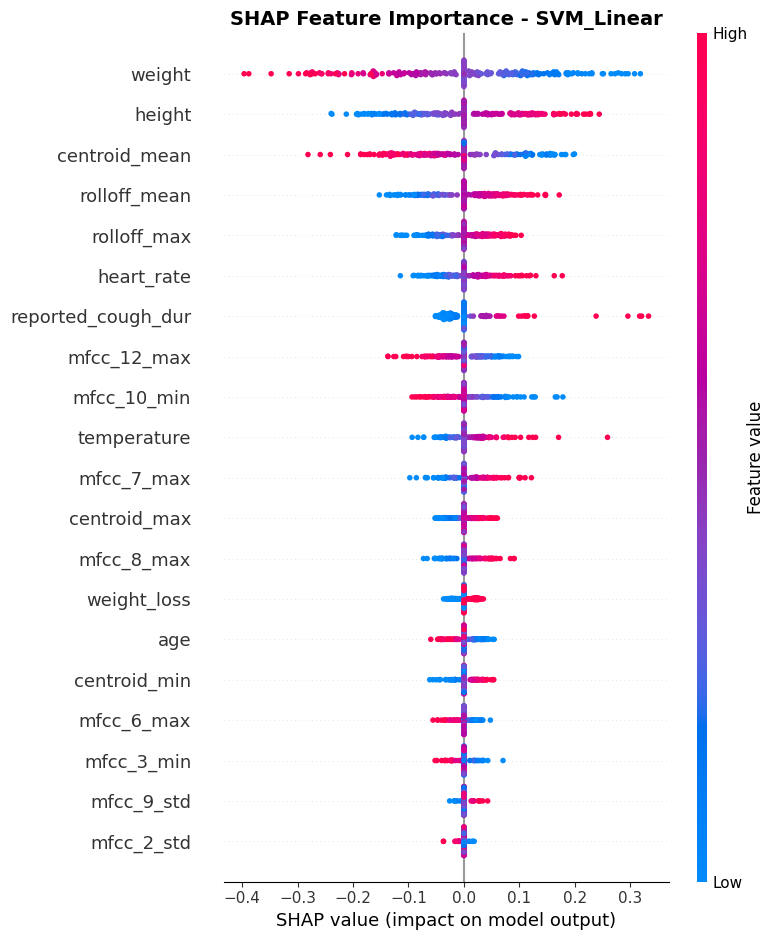

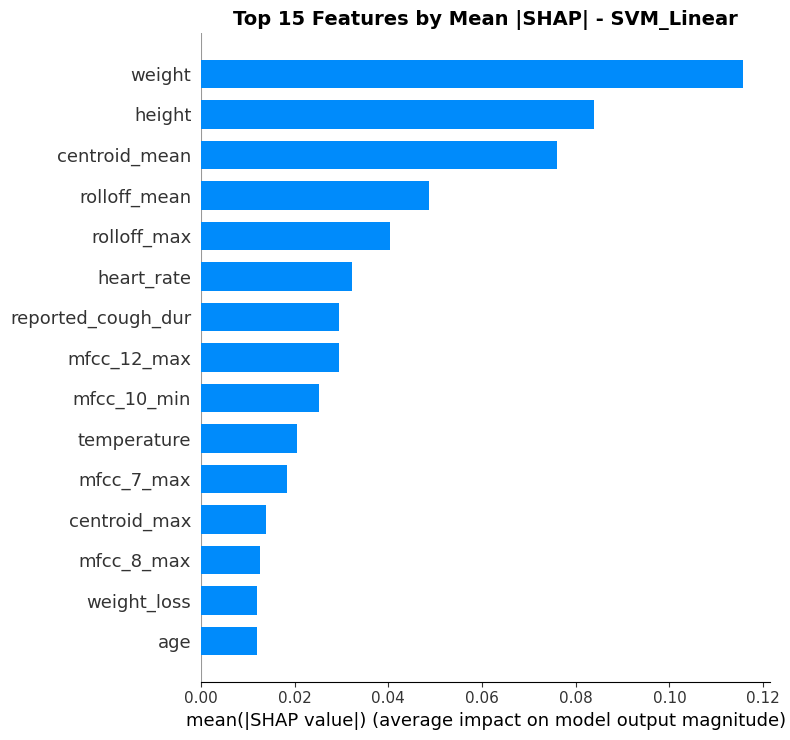


 Comparing SHAP with Native Feature Importance

SVM_Linear doesn't have native feature_importances_

Top 10 Features by SHAP Importance:
               Feature  SHAP_Importance
2               weight         0.115749
1               height         0.083874
19       centroid_mean         0.075969
22        rolloff_mean         0.048614
23         rolloff_max         0.040253
4           heart_rate         0.032242
3   reported_cough_dur         0.029524
18         mfcc_12_max         0.029432
17         mfcc_10_min         0.025117
5          temperature         0.020416


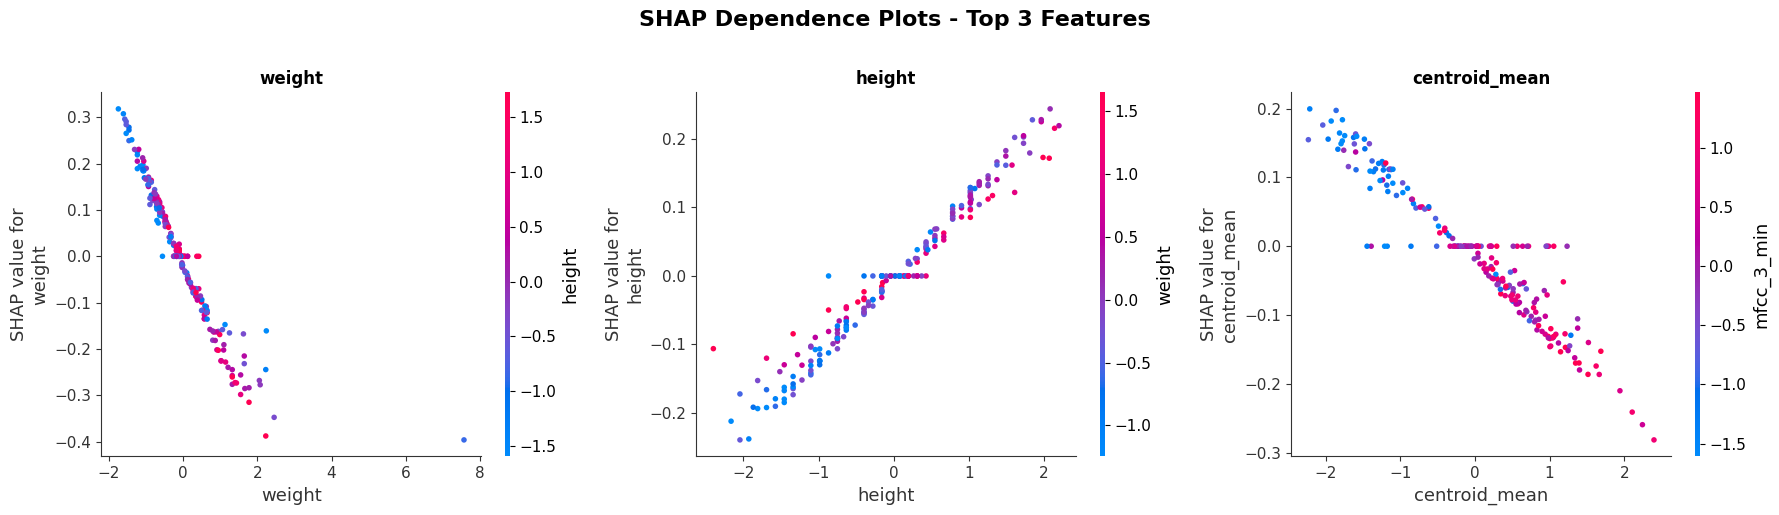

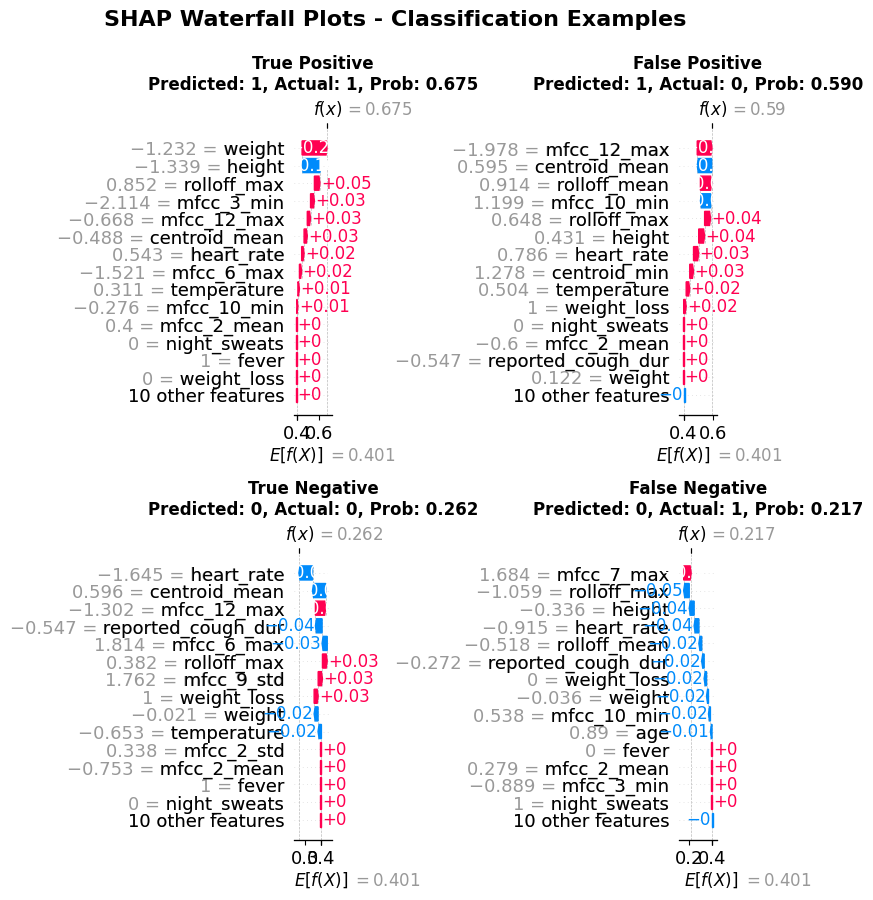

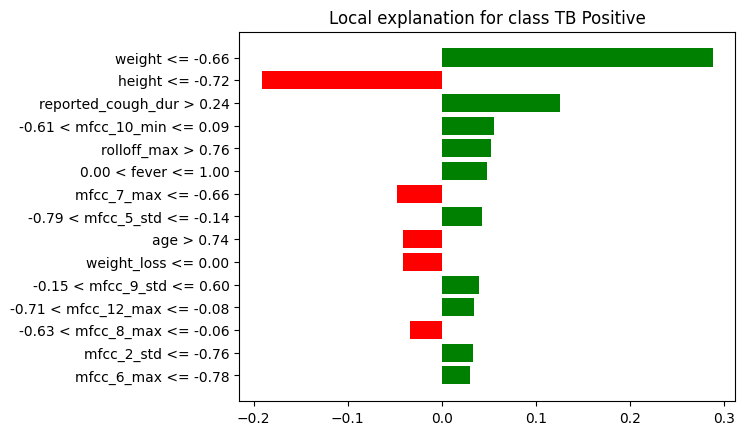

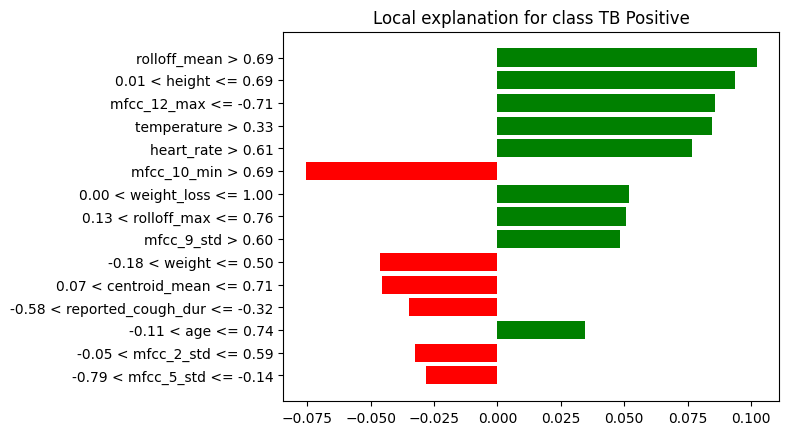

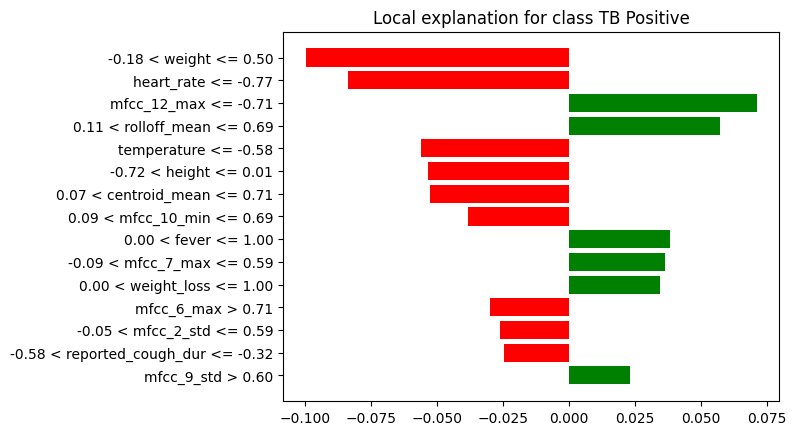

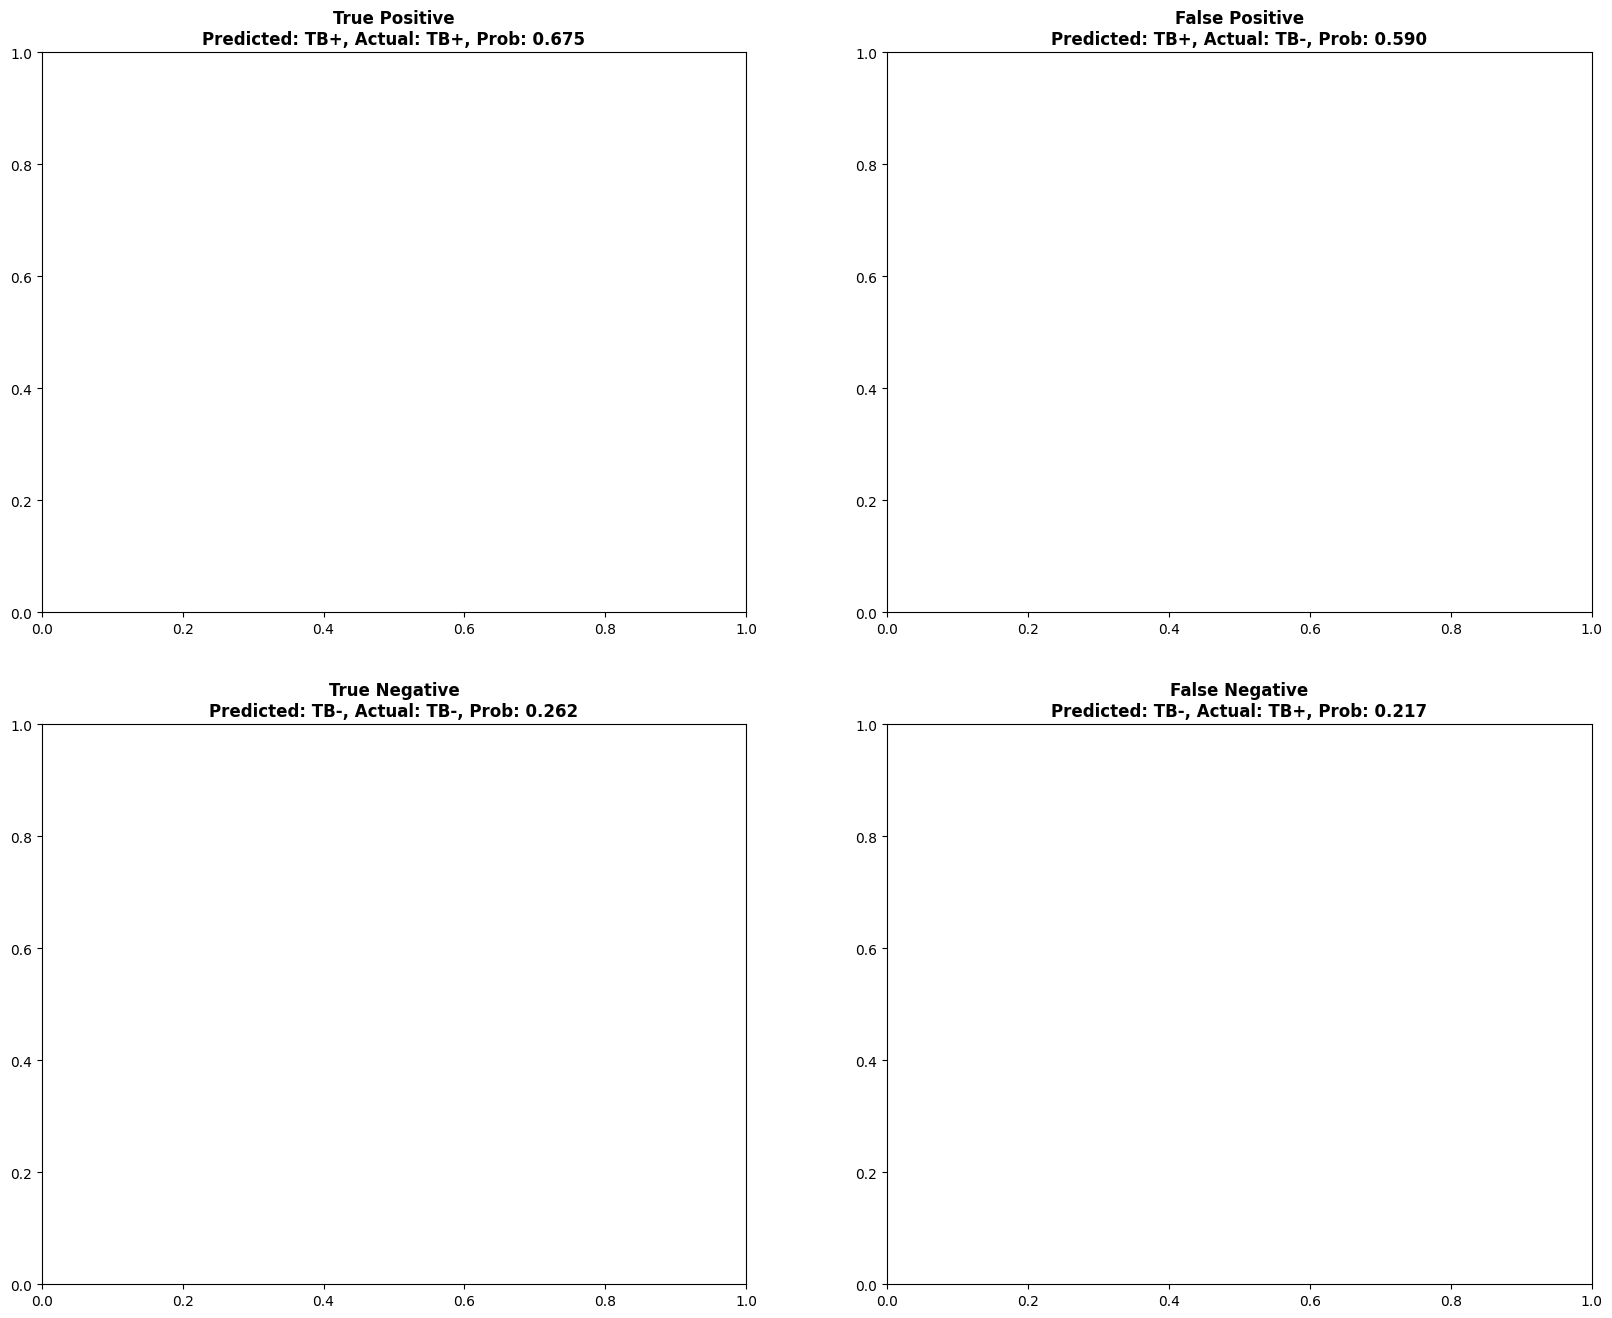

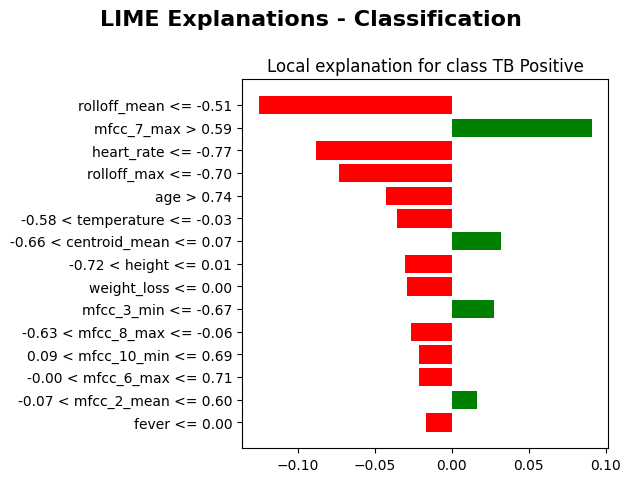


 Comparing SHAP and LIME for a Single Prediction

Analyzing test sample #93
True label: 1
Predicted probability: 0.937


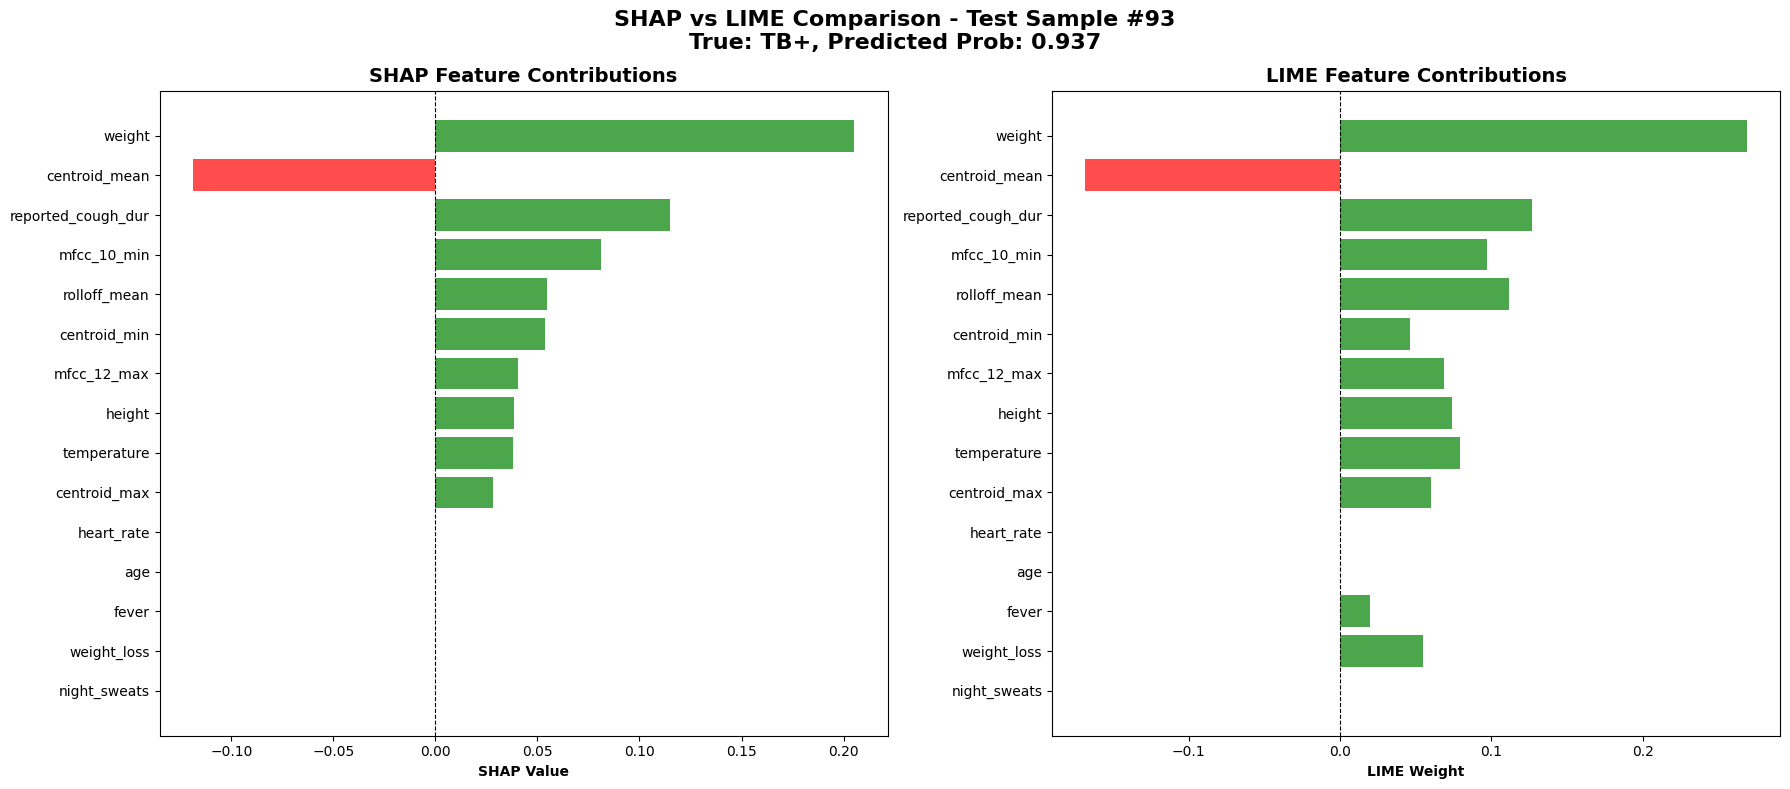


Top 10 Features - SHAP vs LIME:
               Feature  SHAP_Value  LIME_Value
2               weight    0.205324    0.268638
19       centroid_mean   -0.118918   -0.168258
3   reported_cough_dur    0.114803    0.126518
17         mfcc_10_min    0.081172    0.096962
22        rolloff_mean    0.054731    0.111763
20        centroid_min    0.053803    0.046519
18         mfcc_12_max    0.040560    0.068728
1               height    0.038354    0.073743
5          temperature    0.037813    0.079482
21        centroid_max    0.028048    0.060120

Top 10 Most Important Features (by mean |SHAP|):
  3. weight                         (Clinical): 0.1157
  2. height                         (Clinical): 0.0839
  20. centroid_mean                  (Audio   ): 0.0760
  23. rolloff_mean                   (Audio   ): 0.0486
  24. rolloff_max                    (Audio   ): 0.0403
  5. heart_rate                     (Clinical): 0.0322
  4. reported_cough_dur             (Clinical): 0.0295
  19. mfcc_1

In [274]:
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

# Select best model for detailed analysis
best_model_name = final_comparison.loc[final_comparison['Test_F1'].idxmax(), 'Model']
best_model = final_models[best_model_name]

print(f"\nAnalyzing model: {best_model_name}")

# Initialize SHAP explainer based on model type
if 'XGBoost' in best_model_name:
    print("Using TreeExplainer for XGBoost...")
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_processed)

elif 'RandomForest' in best_model_name:
    print("Using TreeExplainer for Random Forest...")
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_processed)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

else:  # LogReg or SVM
    print("Using KernelExplainer")
    background = shap.sample(X_train_processed, 100)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_test_processed)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    # Handle 3D array from KernelExplainer (samples, features, classes)
    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]  # Extract class 1 (TB positive)

print(f"SHAP values shape: {shap_values.shape}")

# Use 2D shap_values for plotting
shap_values_plot = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

# Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_plot, X_test_processed,
                  feature_names=best_features,
                  max_display=20,
                  show=False)
plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Bar Plot

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_plot, X_test_processed,
                  feature_names=best_features,
                  plot_type="bar",
                  max_display=15,
                  show=False)
plt.title(f'Top 15 Features by Mean |SHAP| - {best_model_name}',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# VISUALIZATION

print("\n Comparing SHAP with Native Feature Importance")

# Get mean absolute SHAP values
if len(shap_values.shape) == 3:
    shap_values_2d = shap_values[:, :, 1]  # class 1
else:
    shap_values_2d = shap_values

shap_importance = np.abs(shap_values_2d).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': best_features,
    'SHAP_Importance': shap_importance
}).sort_values('SHAP_Importance', ascending=False)

# Get native feature importance if available
if hasattr(best_model, 'feature_importances_'):
    native_importance = best_model.feature_importances_
    native_importance_df = pd.DataFrame({
        'Feature': best_features,
        'Native_Importance': native_importance
    }).sort_values('Native_Importance', ascending=False)

    # Merge and compare
    comparison_imp = pd.merge(
        shap_importance_df,
        native_importance_df,
        on='Feature'
    )

    # Normalize for comparison
    comparison_imp['SHAP_Norm'] = comparison_imp['SHAP_Importance'] / comparison_imp['SHAP_Importance'].max()
    comparison_imp['Native_Norm'] = comparison_imp['Native_Importance'] / comparison_imp['Native_Importance'].max()

    # Plot comparison
    fig, ax = plt.subplots(figsize=(12, 8))
    top_n = 15
    top_features = comparison_imp.nlargest(top_n, 'SHAP_Norm')

    x = np.arange(len(top_features))
    width = 0.35

    ax.barh(x - width/2, top_features['SHAP_Norm'], width,
            label='SHAP Importance', color='steelblue', alpha=0.8)
    ax.barh(x + width/2, top_features['Native_Norm'], width,
            label='Native Importance', color='coral', alpha=0.8)

    ax.set_yticks(x)
    ax.set_yticklabels(top_features['Feature'])
    ax.set_xlabel('Normalized Importance', fontweight='bold')
    ax.set_title(f'SHAP vs Native Feature Importance - {best_model_name}',
                 fontsize=14, fontweight='bold')
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nTop 10 Features - SHAP vs Native Importance:")
    print(comparison_imp[['Feature', 'SHAP_Importance', 'Native_Importance']].head(10))

else:
    print(f"\n{best_model_name} doesn't have native feature_importances_")
    print("\nTop 10 Features by SHAP Importance:")
    print(shap_importance_df.head(10))

# Dependence Plots

top_3_features = shap_importance_df.head(3)['Feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

shap_values_dep = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
for idx, feature in enumerate(top_3_features):
    feature_idx = best_features.index(feature)
    shap.dependence_plot(
        feature_idx,
        shap_values_dep,
        X_test_processed,
        feature_names=best_features,
        ax=axes[idx],
        show=False
    )
    axes[idx].set_title(f'{feature}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots - Top 3 Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Individual Predictions (Waterfall Plots)

shap_values_ind = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
# Get predictions for test set
y_pred_proba = best_model.predict_proba(X_test_processed)[:, 1]
y_pred = (y_pred_proba >= final_test_results[best_model_name]['threshold']).astype(int)

# Find interesting cases
true_positives = np.where((y_pred == 1) & (y_test == 1))[0]
false_positives = np.where((y_pred == 1) & (y_test == 0))[0]
true_negatives = np.where((y_pred == 0) & (y_test == 0))[0]
false_negatives = np.where((y_pred == 0) & (y_test == 1))[0]

# Select one case from each category
cases = {
    'True Positive': true_positives[0] if len(true_positives) > 0 else None,
    'False Positive': false_positives[0] if len(false_positives) > 0 else None,
    'True Negative': true_negatives[0] if len(true_negatives) > 0 else None,
    'False Negative': false_negatives[0] if len(false_negatives) > 0 else None
}

# Create waterfall plots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

for idx, (case_type, case_idx) in enumerate(cases.items()):
    if case_idx is not None:
        # Create explanation object for waterfall plot
        expected_value = explainer.expected_value
        if isinstance(expected_value, np.ndarray):
          if len(expected_value.shape) > 0:
            expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]

        shap_explanation = shap.Explanation(
            values=shap_values_ind[case_idx],
            base_values=expected_value,
            data=X_test_processed.iloc[case_idx].values,
            feature_names=best_features
        )

        plt.sca(axes[idx])
        shap.waterfall_plot(shap_explanation, max_display=15, show=False)
        axes[idx].set_title(
            f'{case_type}\nPredicted: {y_pred[case_idx]}, Actual: {y_test.iloc[case_idx]}, '
            f'Prob: {y_pred_proba[case_idx]:.3f}',
            fontweight='bold', fontsize=12
        )

plt.suptitle('SHAP Waterfall Plots - Classification Examples',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# LIME

# Initialize LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed.values,
    feature_names=best_features,
    class_names=['TB Negative', 'TB Positive'],
    mode='classification',
    random_state=42
)


fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

for idx, (case_type, case_idx) in enumerate(cases.items()):
    if case_idx is not None:
        # Generate LIME explanation
        lime_exp = lime_explainer.explain_instance(
            data_row=X_test_processed.iloc[case_idx].values,
            predict_fn=best_model.predict_proba,
            num_features=15,
            num_samples=1000
        )

        # Plot in subplot
        plt.sca(axes[idx])
        lime_exp.as_pyplot_figure(label=1)  # Explain class 1 (TB positive)

        axes[idx].set_title(
            f'{case_type}\n'
            f'Predicted: {"TB+" if y_pred[case_idx]==1 else "TB-"}, '
            f'Actual: {"TB+" if y_test.iloc[case_idx]==1 else "TB-"}, '
            f'Prob: {y_pred_proba[case_idx]:.3f}',
            fontweight='bold', fontsize=12
        )

plt.suptitle('LIME Explanations - Classification ',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n Comparing SHAP and LIME for a Single Prediction")

# Choose a high-confidence true positive
if len(true_positives) > 0:
    sample_idx = true_positives[np.argmax(y_pred_proba[true_positives])]

    print(f"\nAnalyzing test sample #{sample_idx}")
    print(f"True label: {y_test.iloc[sample_idx]}")
    print(f"Predicted probability: {y_pred_proba[sample_idx]:.3f}")

    # Get SHAP values for this sample
    # Get SHAP values for this sample (ensure 2D)
    shap_values_comp = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
    sample_shap = shap_values_comp[sample_idx]

    # Get LIME explanation
    lime_exp = lime_explainer.explain_instance(
        data_row=X_test_processed.iloc[sample_idx].values,
        predict_fn=best_model.predict_proba,
        num_features=15,
        num_samples=2000
    )

    # Extract LIME weights
    lime_weights = dict(lime_exp.as_list(label=1))

    # Create comparison dataframe
    comparison = pd.DataFrame({
        'Feature': best_features,
        'SHAP_Value': sample_shap
    })

    # Add LIME values (matching feature names)
    lime_values = []
    for feat in best_features:
        matched = False
        for lime_feat, lime_val in lime_weights.items():
            if feat in lime_feat or lime_feat in feat:
                lime_values.append(lime_val)
                matched = True
                break
        if not matched:
            lime_values.append(0)

    comparison['LIME_Value'] = lime_values

    # Sort by absolute SHAP value
    comparison['abs_shap'] = np.abs(comparison['SHAP_Value'])
    comparison = comparison.sort_values('abs_shap', ascending=False).head(15)

    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # SHAP
    y_pos = np.arange(len(comparison))
    colors_shap = ['green' if x > 0 else 'red' for x in comparison['SHAP_Value']]
    ax1.barh(y_pos, comparison['SHAP_Value'], color=colors_shap, alpha=0.7)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(comparison['Feature'])
    ax1.set_xlabel('SHAP Value', fontweight='bold')
    ax1.set_title('SHAP Feature Contributions', fontweight='bold', fontsize=14)
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    ax1.invert_yaxis()

    # LIME
    colors_lime = ['green' if x > 0 else 'red' for x in comparison['LIME_Value']]
    ax2.barh(y_pos, comparison['LIME_Value'], color=colors_lime, alpha=0.7)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(comparison['Feature'])
    ax2.set_xlabel('LIME Weight', fontweight='bold')
    ax2.set_title('LIME Feature Contributions', fontweight='bold', fontsize=14)
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    ax2.invert_yaxis()

    plt.suptitle(
        f'SHAP vs LIME Comparison - Test Sample #{sample_idx}\n'
        f'True: TB+, Predicted Prob: {y_pred_proba[sample_idx]:.3f}',
        fontsize=16, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    # Print numerical comparison
    print("\nTop 10 Features - SHAP vs LIME:")
    print(comparison[['Feature', 'SHAP_Value', 'LIME_Value']].head(10))



# Global feature importance from SHAP
print("\nTop 10 Most Important Features (by mean |SHAP|):")
for idx, row in shap_importance_df.head(10).iterrows():
    feat_type = "Clinical" if row['Feature'] in clinical_features else "Audio"
    print(f"  {idx+1}. {row['Feature']:30s} ({feat_type:8s}): {row['SHAP_Importance']:.4f}")

# Feature type breakdown
clinical_shap = shap_importance_df[shap_importance_df['Feature'].isin(clinical_features)]['SHAP_Importance'].sum()
audio_shap = shap_importance_df[~shap_importance_df['Feature'].isin(clinical_features)]['SHAP_Importance'].sum()

print(f"\nFeature Type Contribution:")
print(f"  Clinical features: {clinical_shap:.4f} ({clinical_shap/(clinical_shap+audio_shap)*100:.1f}%)")
print(f"  Audio features:    {audio_shap:.4f} ({audio_shap/(clinical_shap+audio_shap)*100:.1f}%)")
